# Section 3 — H1 → Daily Ensemble: Held-out Results

This notebook **evaluates the models produced by `_train_pipeline.py` Section 13**
(the auxiliary H1→Daily predictor). It loads the four serialized regressors from
`models/` — **XGBoost, Random Forest, SVM (RBF), and a sequence-to-vector LSTM** —
reproduces the *exact* chronological 80/20 test split used during training, and
reports each model's performance on the untouched hold-out set.

All four forecast the **next-day (t+1) percentage return**. We report **MAE / RMSE
/ R²** (regression quality) and **directional accuracy / ROC-AUC** (does the sign
of the prediction discriminate up vs down days), each against a
predict-the-mean baseline.

In [ ]:
import os, sys, json
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt

# The notebook runs from notebooks/, so make the repo root importable and
# resolve every artifact/data path relative to it.
ROOT = os.path.abspath("..")
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)
os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "3")

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, roc_auc_score, accuracy_score
from sklearn.dummy import DummyRegressor
from src.h1_features import build_h1_datasets

CONFIG = json.load(open(os.path.join(ROOT, "config.json")))
MODELS = os.path.join(ROOT, "models")
plt.rcParams["figure.figsize"] = (11, 4)
print("Repo root:", ROOT)

Repo root: C:\Users\test\Desktop\eurusdprophet


## 1 · Rebuild the identical held-out test set

We regenerate the aligned H1 datasets and apply the **same** `train_fraction`
(0.80) chronological cut as training, so the numbers below reproduce exactly what
the pipeline evaluated — no shuffling, no re-tuning, no leakage.

In [ ]:
Xf, Xseq, y_ret, y_dir, idx = build_h1_datasets(
    cache_path=os.path.join(ROOT, "results", "eurusd_h1.csv"))

n = len(Xf)
split = int(n * CONFIG["split"]["train_fraction"])
te = slice(split, n)

X_flat_te = Xf.values[te]
y_ret_te, y_dir_te = y_ret[te], y_dir[te]
test_index = idx[te]

print(f"{n} total days  |  train = first {split}  |  test = last {n - split}")
print(f"Test window: {test_index.min().date()} -> {test_index.max().date()}")
print(f"Test up/down balance: {y_dir_te.mean():.3f} up")

2500 total days  |  train = first 2000  |  test = last 500
Test window: 2024-07-29 -> 2026-07-02
Test up/down balance: 0.468 up


## 2 · Load the trained artifacts

The scalers are the **fitted** objects from training, so applying them here
reproduces training's preprocessing exactly: the RBF SVM sees scaled features, the
scale-invariant tree models see raw features, and the LSTM sees the per-hour
scaled 24-step tensor.

In [ ]:
h1_xgb = joblib.load(os.path.join(MODELS, "h1_xgb_regressor.pkl"))
h1_rf  = joblib.load(os.path.join(MODELS, "h1_rf_regressor.pkl"))
h1_svm = joblib.load(os.path.join(MODELS, "h1_svm_regressor.pkl"))
feat_scaler = joblib.load(os.path.join(MODELS, "h1_feature_scaler.pkl"))
seq_scaler  = joblib.load(os.path.join(MODELS, "h1_lstm_scaler.pkl"))
feat_cols   = joblib.load(os.path.join(MODELS, "h1_feature_columns.pkl"))
if hasattr(h1_xgb, "set_params"):
    h1_xgb.set_params(device="cpu")   # portable CPU inference

from tensorflow.keras.models import load_model
h1_lstm = load_model(os.path.join(MODELS, "h1_lstm.keras"))

# Best hyper-parameters the GridSearch settled on (trees/SVM):
print("XGBoost :", {k: h1_xgb.get_params()[k] for k in ('n_estimators', 'learning_rate', 'max_depth')})
print("Forest  :", {k: h1_rf.get_params()[k] for k in ('n_estimators', 'max_depth')})
print("SVM     :", {k: h1_svm.get_params()[k] for k in ('C', 'gamma')})
print("LSTM    :", h1_lstm.count_params(), "params")

XGBoost : {'n_estimators': 100, 'learning_rate': 0.01, 'max_depth': 3}
Forest  : {'n_estimators': 400, 'max_depth': 4}
SVM     : {'C': 0.1, 'gamma': 0.1}
LSTM    : 4769 params


## 3 · Predict on the hold-out set & score every model

In [ ]:
X_flat_te_s = feat_scaler.transform(X_flat_te)                 # SVM input (scaled)
nf = Xseq.shape[2]
Xseq_s = seq_scaler.transform(Xseq.reshape(-1, nf)).reshape(Xseq.shape).astype("float32")
Xseq_te_s = Xseq_s[te]                                          # LSTM input (scaled tensor)

preds = {
    "XGBoost":      h1_xgb.predict(X_flat_te),
    "RandomForest": h1_rf.predict(X_flat_te),
    "SVM (RBF)":    h1_svm.predict(X_flat_te_s),
    "LSTM":         h1_lstm.predict(Xseq_te_s, verbose=0).ravel(),
}

def score(name, p):
    return {
        "Model": name,
        "MAE (%)":  mean_absolute_error(y_ret_te, p),
        "RMSE (%)": mean_squared_error(y_ret_te, p) ** 0.5,
        "R2":       r2_score(y_ret_te, p),
        "Dir.Acc":  accuracy_score(y_dir_te, (p > 0).astype(int)),
        "ROC-AUC":  roc_auc_score(y_dir_te, p) if len(np.unique(y_dir_te)) > 1 else np.nan,
    }

baseline_pred = DummyRegressor(strategy="mean").fit(Xf.values[:split], y_ret[:split]).predict(X_flat_te)
table = pd.DataFrame(
    [score("Baseline (mean)", baseline_pred)] + [score(k, v) for k, v in preds.items()]
).set_index("Model").round(4)
table

,MAE (%),RMSE (%),R2,Dir.Acc,ROC-AUC
Model,,,,,
Baseline (mean),0.3380,0.4564,-0.0006,0.532,0.5000
XGBoost,0.3411,0.4648,-0.0377,0.482,0.5196
RandomForest,0.3458,0.4706,-0.0637,0.478,0.5119
SVM (RBF),0.3409,0.4582,-0.0086,0.508,0.5165
LSTM,0.3379,0.4583,-0.0089,0.506,0.5020


## 4 · Visual comparison

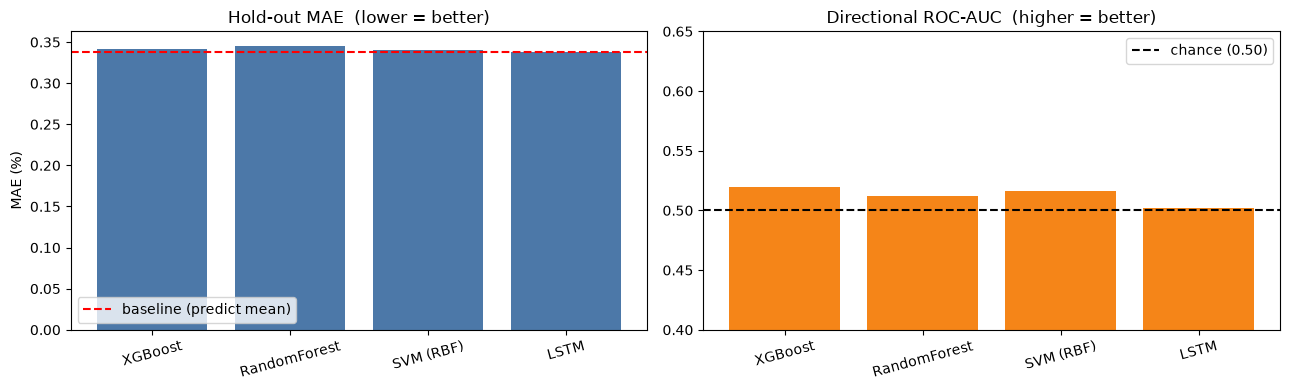

In [ ]:
m = table.drop(index="Baseline (mean)")
fig, ax = plt.subplots(1, 2, figsize=(13, 4))

ax[0].bar(m.index, m["MAE (%)"], color="#4C78A8")
ax[0].axhline(table.loc["Baseline (mean)", "MAE (%)"], color="r", ls="--", label="baseline (predict mean)")
ax[0].set_title("Hold-out MAE  (lower = better)"); ax[0].set_ylabel("MAE (%)")
ax[0].legend(); ax[0].tick_params(axis="x", rotation=15)

ax[1].bar(m.index, m["ROC-AUC"], color="#F58518")
ax[1].axhline(0.5, color="k", ls="--", label="chance (0.50)")
ax[1].set_ylim(0.40, 0.65); ax[1].set_title("Directional ROC-AUC  (higher = better)")
ax[1].legend(); ax[1].tick_params(axis="x", rotation=15)
plt.tight_layout(); plt.show()

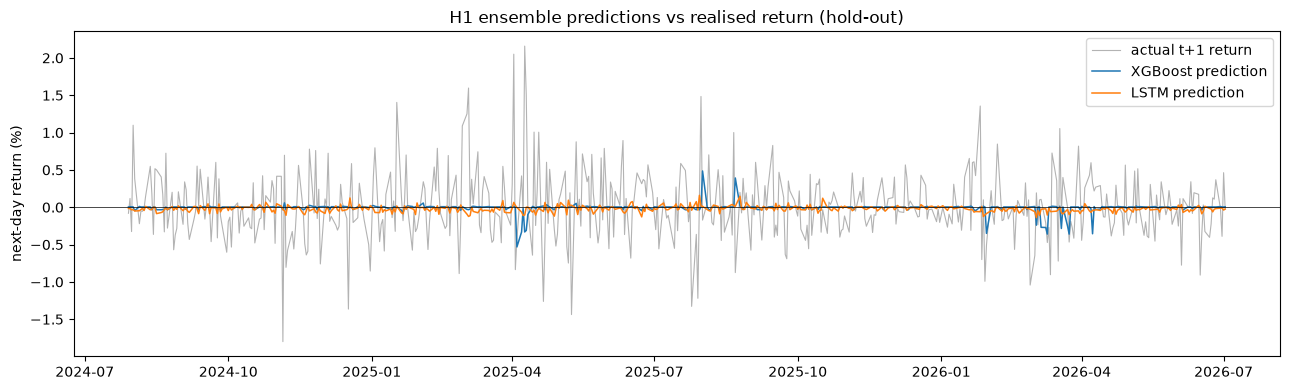

Prediction spread vs actual (std, %):
  actual        0.4563
  XGBoost       0.0623
  RandomForest  0.0853
  SVM (RBF)     0.0563
  LSTM          0.0402


In [ ]:
# Predictions vs the realised next-day return over the test window. The tell-tale
# sign of an honest near-efficient forecaster: predictions are heavily shrunk
# toward the ~0% mean relative to the noisy actual series.
fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(test_index, y_ret_te, color="0.7", lw=0.8, label="actual t+1 return")
for name in ["XGBoost", "LSTM"]:
    ax.plot(test_index, preds[name], lw=1.1, label=f"{name} prediction")
ax.axhline(0, color="k", lw=0.5)
ax.set_ylabel("next-day return (%)"); ax.set_title("H1 ensemble predictions vs realised return (hold-out)")
ax.legend(); plt.tight_layout(); plt.show()

print("Prediction spread vs actual (std, %):")
print(f"  actual        {y_ret_te.std():.4f}")
for name, p in preds.items():
    print(f"  {name:13s} {p.std():.4f}")

## 5 · The live consensus (exactly what `/api/predict` serves)

This is the same `PredictionService._predict_h1()` path the API uses, run on the
latest **completed** trading day — so the notebook and the endpoint agree.

In [ ]:
from src.inference import PredictionService
svc = PredictionService(ROOT, CONFIG)
per_model, as_of = svc._predict_h1()
consensus = svc.compute_h1_consensus(per_model)

print(f"Latest completed day: {as_of}\n")
for name, p in per_model.items():
    print(f"  {name:18s} {p['direction']:4s}  {p['predicted_return_pct']:+.4f}%")
print("\nH1 consensus ->", consensus)

Latest completed day: 2026-07-03

  h1_xgboost         UP    +0.0038%
  h1_random_forest   UP    +0.0049%
  h1_svm             DOWN  -0.0219%
  h1_lstm            UP    +0.0501%

H1 consensus -> {'direction': 'UP', 'agreement': False, 'confidence': 0.75, 'predicted_return_pct': 0.009244495652200391, 'n_models': 4}


## 6 · Interpretation

Read these results through the project's **mathematical-honesty** lens
(`ARCHITECTURE_DOCS.md` §4.2.1): daily EUR/USD is **near-efficient**, so:

* **ROC-AUC ≈ 0.50** and directional accuracy ≈ 0.50 — the sign of tomorrow's
  return is close to unforecastable from intraday statistics alone.
* **R² ≈ 0 (often slightly negative)** and every model's **MAE ≈ the baseline's** —
  the regressors correctly **shrink toward the ~0% conditional mean** rather than
  hallucinating a signal (visible as the flat prediction lines above).

That is the *expected and correct* outcome, not a bug. A model that beat the
baseline by a wide margin here would be a leakage red flag. The deliverable's
worth is the **engineering**: a leak-free H1→Daily pipeline, four independently
trained model families (bagging / boosting / kernel / recurrent), and a live
serving path — all reproducible from `_train_pipeline.py`.